In [1]:
import os, json, warnings, textwrap
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report
import shap

OUTPUT_DIR = 'output'
os.makedirs(OUTPUT_DIR, exist_ok=True)

c:\Users\30222\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
JURISDICTION_CONFIG = {
    'US': {
        'name': 'US Regulation B / ECOA',
        'primary_metric':  'disparate_impact_ratio',
        'threshold_type':  'min',
        'threshold_value':  0.80,
        'secondary_metric': None,
        'remediation_note': (
            'DIR < 0.80 signals potential disparate impact under US law. '
        ),
    },
    'EU': {
        'name': 'EU AI Act',
        'primary_metric':  'demographic_parity_difference',
        'threshold_type':  'max',
        'threshold_value':  0.05,
        'secondary_metric': 'equalised_odds_difference',
        'remediation_note': (
            'DPD > 5pp triggers mandatory bias-mitigation review under EU AI Act. '
        ),
    },
}
SENSITIVITY_CONFIG = {
    'threshold_quantiles': list(np.linspace(0.20, 0.80, 13)),
}
for jk, jv in JURISDICTION_CONFIG.items():
    direction = '>=' if jv['threshold_type'] == 'min' else '<='
    print(f"  {jk}: {jv['primary_metric']} {direction} {jv['threshold_value']}")


  US: disparate_impact_ratio >= 0.8
  EU: demographic_parity_difference <= 0.05


In [3]:
CSV_PATH = 'German Credit Data(german).csv'

df_raw = pd.read_csv(CSV_PATH, sep=None, engine='python')
print(f'dataset: {df_raw.shape[0]} rows x {df_raw.shape[1]} columns')

df_raw['gender']   = df_raw['status n sex'].apply(
    lambda x: 'Female' if x in ['A92', 'A95'] else 'Male'
)
df_raw['approved'] = df_raw['Category'].apply(lambda x: 1 if x == 1 else 0)

print('\nClass balance:')
print(df_raw['approved'].value_counts().rename({1:'Good(Approved)', 0:'Bad(Rejected)'}))
print('\nGender distribution:')
print(df_raw['gender'].value_counts())

drop_cols        = [c for c in ['Category','approved','status n sex','gender'] if c in df_raw.columns]
features_raw     = df_raw.drop(columns=drop_cols)
features_encoded = pd.get_dummies(features_raw, drop_first=True).astype(float).fillna(0)
target           = df_raw['approved']

print(f'\nFeature matrix: {features_encoded.shape[0]} samples x {features_encoded.shape[1]} features')


dataset: 1000 rows x 21 columns

Class balance:
approved
Good(Approved)    700
Bad(Rejected)     300
Name: count, dtype: int64

Gender distribution:
gender
Male      690
Female    310
Name: count, dtype: int64

Feature matrix: 1000 samples x 45 features


In [4]:
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(features_encoded)

model = LogisticRegression(max_iter=1000, C=1.0, random_state=42)
model.fit(X_scaled, target)

df_raw['model_score']    = model.predict_proba(X_scaled)[:, 1] * 100
BASE_THRESHOLD           = df_raw['model_score'].quantile(1 - df_raw['approved'].mean())
df_raw['model_decision'] = (df_raw['model_score'] >= BASE_THRESHOLD).astype(int)

print('Model training complete.')
print(f"  Features   : {features_encoded.shape[1]}")
print(f"  Threshold  : {BASE_THRESHOLD:.2f}  (reproduces historical approval rate)")
print(f"  Model appr.: {df_raw['model_decision'].mean():.1%}")
print(f"  Hist. appr.: {df_raw['approved'].mean():.1%}")
print()
print(classification_report(
    df_raw['approved'], model.predict(X_scaled),
    target_names=['Bad Credit','Good Credit'], digits=3
))


Model training complete.
  Features   : 45
  Threshold  : 58.53  (reproduces historical approval rate)
  Model appr.: 70.0%
  Hist. appr.: 70.0%

              precision    recall  f1-score   support

  Bad Credit      0.679     0.543     0.604       300
 Good Credit      0.820     0.890     0.853       700

    accuracy                          0.786      1000
   macro avg      0.749     0.717     0.729      1000
weighted avg      0.778     0.786     0.779      1000



In [5]:
def safe_div(a, b):
    return np.nan if (b == 0 or np.isnan(b)) else a / b

def compute_fairness_metrics(df, decision_col='model_decision'):
    gm = df[df['gender'] == 'Male']
    gf = df[df['gender'] == 'Female']
    pm = gm[decision_col].mean()
    pf = gf[decision_col].mean()

    def tpr(g):
        pos = g[g['approved'] == 1]
        return pos[decision_col].mean() if len(pos) > 0 else np.nan

    def fpr(g):
        neg = g[g['approved'] == 0]
        return neg[decision_col].mean() if len(neg) > 0 else np.nan

    eod = max(abs(tpr(gm) - tpr(gf)), abs(fpr(gm) - fpr(gf)))

    return {
        'approval_rate_privileged':      pm,
        'approval_rate_unprivileged':    pf,
        'approval_rate_diff':            pm - pf,
        'disparate_impact_ratio':        safe_div(pf, pm),
        'demographic_parity_difference': abs(pm - pf),
        'equalised_odds_difference':     eod,
        'n_privileged':                  len(gm),
        'n_unprivileged':                len(gf),
    }

def evaluate_jurisdiction(metrics, jk, jcfg):
    val = metrics.get(jcfg['primary_metric'], np.nan)
    if pd.isna(val):
        status = 'REVIEW'
    elif jcfg['threshold_type'] == 'min':
        status = 'PASS' if val >= jcfg['threshold_value'] else 'FAIL'
    else:
        status = 'PASS' if val <= jcfg['threshold_value'] else 'FAIL'

    sec_metric = jcfg['secondary_metric']
    sec_val    = metrics.get(sec_metric, np.nan) if sec_metric else np.nan
    thr_dir    = '>=' if jcfg['threshold_type'] == 'min' else '<='
    thr_str    = thr_dir + ' ' + str(jcfg['threshold_value'])
    note       = jcfg['remediation_note'] if status == 'FAIL' else 'No action required.'

    return {
        'jurisdiction':     jk,
        'rule_name':        jcfg['name'],
        'primary_metric':   jcfg['primary_metric'],
        'metric_value':     val,
        'threshold':        thr_str,
        'status':           status,
        'secondary_metric': sec_metric,
        'secondary_value':  sec_val,
        'remediation_note': note,
    }

metrics_dict  = compute_fairness_metrics(df_raw, decision_col='model_decision')
audit_results = [
    evaluate_jurisdiction(metrics_dict, jk, jv)
    for jk, jv in JURISDICTION_CONFIG.items()
]
metrics_df = pd.DataFrame([metrics_dict])
audit_df   = pd.DataFrame(audit_results)

print('  BASE FAIRNESS METRICS')
for k, v in metrics_dict.items():
    if isinstance(v, float):
        print(f'  {k:<44} {v:.4f}')
    else:
        print(f'  {k:<44} {v}')

print()
print('  JURISDICTION AUDIT RESULTS')
for _, row in audit_df.iterrows():
    jname   = row['jurisdiction']
    rname   = row['rule_name']
    pmetric = row['primary_metric']
    mval    = row['metric_value']
    thr     = row['threshold']
    status  = row['status']
    note    = row['remediation_note']
    icon    = 'PASS' if status == 'PASS' else 'FAIL'
    print(f'  [{icon}] [{jname}] {rname[:55]}')
    print(f'      Metric  : {pmetric} = {mval:.4f}')
    print(f'      Rule    : {thr}')
    print(f'      Status  : {status}')
    if status == 'FAIL':
        print(f'      >> {note[:110]}')
    print()


  BASE FAIRNESS METRICS
  approval_rate_privileged                     0.7188
  approval_rate_unprivileged                   0.6581
  approval_rate_diff                           0.0608
  disparate_impact_ratio                       0.9155
  demographic_parity_difference                0.0608
  equalised_odds_difference                    0.0624
  n_privileged                                 690
  n_unprivileged                               310

  JURISDICTION AUDIT RESULTS
  [PASS] [US] US Regulation B / ECOA
      Metric  : disparate_impact_ratio = 0.9155
      Rule    : >= 0.8
      Status  : PASS

  [FAIL] [EU] EU AI Act
      Metric  : demographic_parity_difference = 0.0608
      Rule    : <= 0.05
      Status  : FAIL
      >> DPD > 5pp triggers mandatory bias-mitigation review under EU AI Act. 



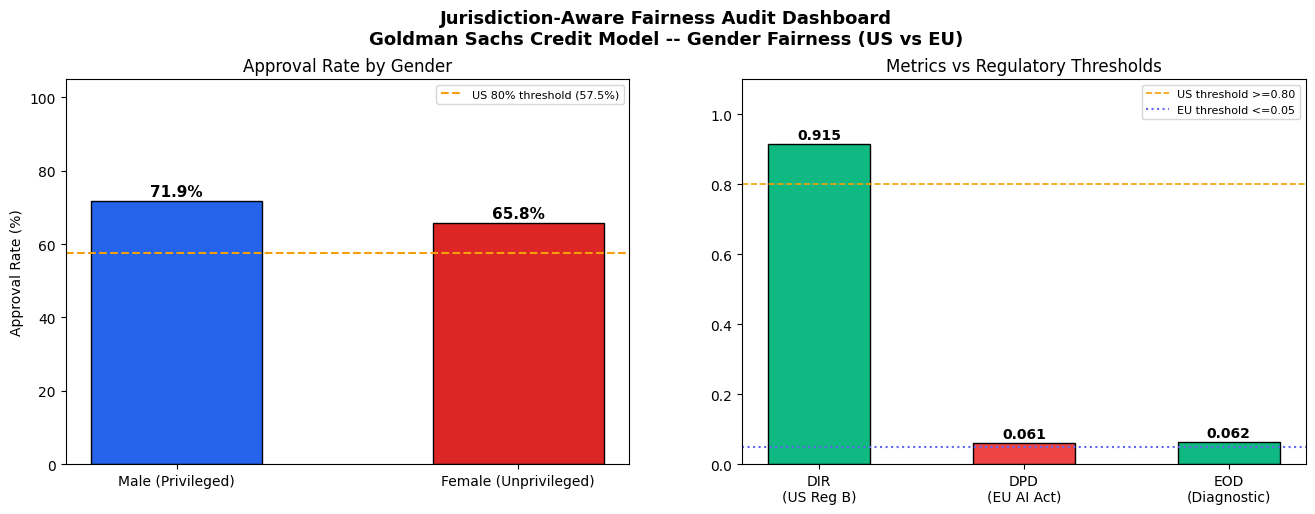

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle(
    'Jurisdiction-Aware Fairness Audit Dashboard\n'
    'Goldman Sachs Credit Model -- Gender Fairness (US vs EU)',
    fontsize=13, fontweight='bold', y=1.02
)

ax1    = axes[0]
groups = ['Male (Privileged)', 'Female (Unprivileged)']
rate_m = metrics_dict['approval_rate_privileged']
rate_f = metrics_dict['approval_rate_unprivileged']
rates  = [rate_m, rate_f]
bars   = ax1.bar(groups, [r * 100 for r in rates],
                 color=['#2563EB', '#DC2626'], width=0.5, edgecolor='k')
for b, r in zip(bars, rates):
    ax1.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.5,
             f'{r:.1%}', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax1.set_ylim(0, 105)
ax1.set_ylabel('Approval Rate (%)')
ax1.set_title('Approval Rate by Gender')
us_line = rate_m * 0.80 * 100
us_label = 'US 80% threshold (' + str(round(us_line, 1)) + '%)'
ax1.axhline(us_line, color='#F59E0B', linestyle='--', linewidth=1.5, label=us_label)
ax1.legend(fontsize=8)

ax2     = axes[1]
mlabels = ['DIR\n(US Reg B)', 'DPD\n(EU AI Act)', 'EOD\n(Diagnostic)']
dir_val = metrics_dict['disparate_impact_ratio']
dpd_val = metrics_dict['demographic_parity_difference']
eod_val = metrics_dict['equalised_odds_difference']
mvals   = [dir_val, dpd_val, eod_val]
thrs    = [0.80, 0.05, 0.10]
tdirs   = ['min', 'max', 'max']
mcols   = []
for v, t, d in zip(mvals, thrs, tdirs):
    if pd.isna(v):
        mcols.append('#9CA3AF')
    elif (d == 'min' and v >= t) or (d == 'max' and v <= t):
        mcols.append('#10B981')
    else:
        mcols.append('#EF4444')
bars2 = ax2.bar(mlabels, mvals, color=mcols, width=0.5, edgecolor='k')
for b, v in zip(bars2, mvals):
    if not pd.isna(v):
        ax2.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.005,
                 f'{v:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax2.axhline(0.80, color='#F59E0B', linestyle='--', linewidth=1.2, label='US threshold >=0.80')
ax2.axhline(0.05, color='#6366F1', linestyle=':',  linewidth=1.5, label='EU threshold <=0.05')
ax2.set_ylim(0, 1.1)
ax2.set_title('Metrics vs Regulatory Thresholds')
ax2.legend(fontsize=8)

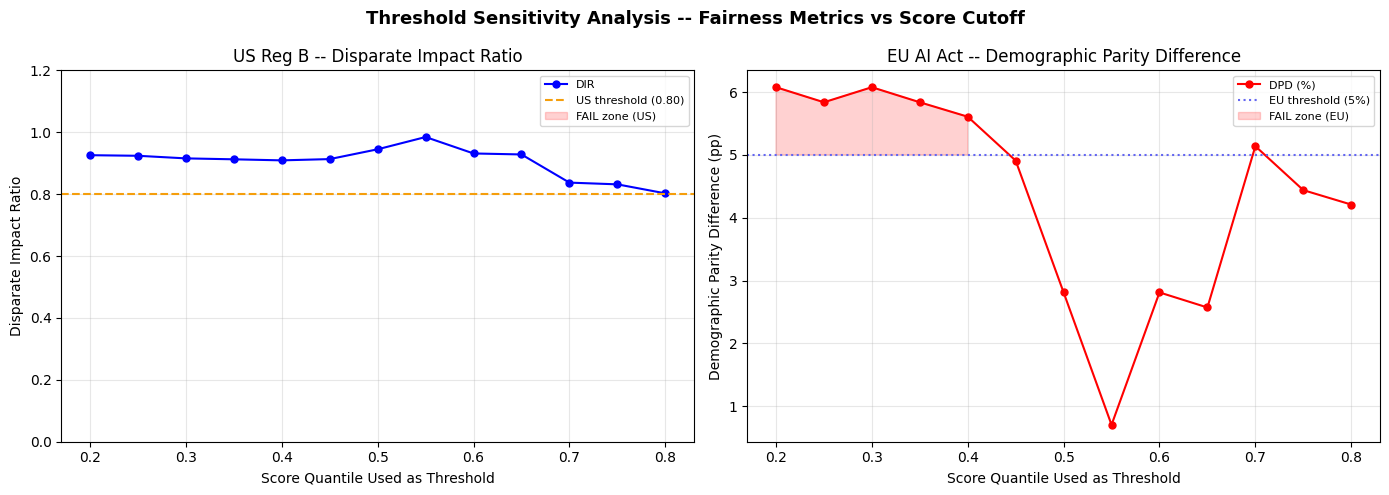

 quantile  threshold    DIR    DPD US_status EU_status
     0.20      45.42 0.9258 0.0608      PASS      FAIL
     0.25      51.96 0.9239 0.0584      PASS      FAIL
     0.30      58.53 0.9155 0.0608      PASS      FAIL
     0.35      64.21 0.9125 0.0584      PASS      FAIL
     0.40      68.74 0.9091 0.0561      PASS      FAIL
     0.45      73.23 0.9132 0.0491      PASS      PASS
     0.50      77.66 0.9449 0.0281      PASS      PASS
     0.55      81.60 0.9845 0.0070      PASS      PASS
     0.60      84.10 0.9314 0.0281      PASS      PASS
     0.65      86.65 0.9282 0.0257      PASS      PASS
     0.70      88.80 0.8372 0.0514      PASS      FAIL
     0.75      91.13 0.8316 0.0444      PASS      PASS
     0.80      93.11 0.8025 0.0421      PASS      PASS


In [7]:
rows = []
scores = df_raw['model_score']

for q in SENSITIVITY_CONFIG['threshold_quantiles']:
    thr = scores.quantile(q)
    tmp = df_raw.copy()
    tmp['_d'] = (tmp['model_score'] >= thr).astype(int)
    gm = tmp[tmp['gender'] == 'Male']
    gf = tmp[tmp['gender'] == 'Female']
    pm = gm['_d'].mean()
    pf = gf['_d'].mean()
    di  = safe_div(pf, pm)
    dpd = abs(pm - pf)
    us_pass = 'PASS' if (not np.isnan(di) and di >= 0.80) else 'FAIL'
    eu_pass = 'PASS' if dpd <= 0.05 else 'FAIL'
    rows.append({
        'quantile':    round(q, 3),
        'threshold':   round(thr, 2),
        'rate_Male':   round(pm, 4),
        'rate_Female': round(pf, 4),
        'DIR':         round(di, 4) if not np.isnan(di) else np.nan,
        'DPD':         round(dpd, 4),
        'US_status':   us_pass,
        'EU_status':   eu_pass,
    })

sens_df = pd.DataFrame(rows)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(
    'Threshold Sensitivity Analysis -- Fairness Metrics vs Score Cutoff',
    fontsize=13, fontweight='bold'
)

qs = sens_df['quantile']
ax1.plot(qs, sens_df['DIR'], 'b-o', markersize=5, label='DIR')
ax1.axhline(0.80, color='#F59E0B', linestyle='--', label='US threshold (0.80)')
ax1.fill_between(qs, sens_df['DIR'], 0.80,
                 where=sens_df['DIR'] < 0.80,
                 alpha=0.18, color='red', label='FAIL zone (US)')
ax1.set_ylim(0, 1.2)
ax1.set_xlabel('Score Quantile Used as Threshold')
ax1.set_ylabel('Disparate Impact Ratio')
ax1.set_title('US Reg B -- Disparate Impact Ratio')
ax1.legend(fontsize=8)
ax1.grid(alpha=0.3)

ax2.plot(qs, sens_df['DPD'] * 100, 'r-o', markersize=5, label='DPD (%)')
ax2.axhline(5.0, color='#6366F1', linestyle=':', label='EU threshold (5%)')
ax2.fill_between(qs, sens_df['DPD'] * 100, 5.0,
                 where=sens_df['DPD'] * 100 > 5.0,
                 alpha=0.18, color='red', label='FAIL zone (EU)')
ax2.set_xlabel('Score Quantile Used as Threshold')
ax2.set_ylabel('Demographic Parity Difference (pp)')
ax2.set_title('EU AI Act -- Demographic Parity Difference')
ax2.legend(fontsize=8)
ax2.grid(alpha=0.3)

plt.tight_layout()
save_path = os.path.join(OUTPUT_DIR, 'threshold_sensitivity.png')
plt.savefig(save_path, bbox_inches='tight')
plt.show()

print(sens_df[['quantile','threshold','DIR','DPD','US_status','EU_status']].to_string(index=False))


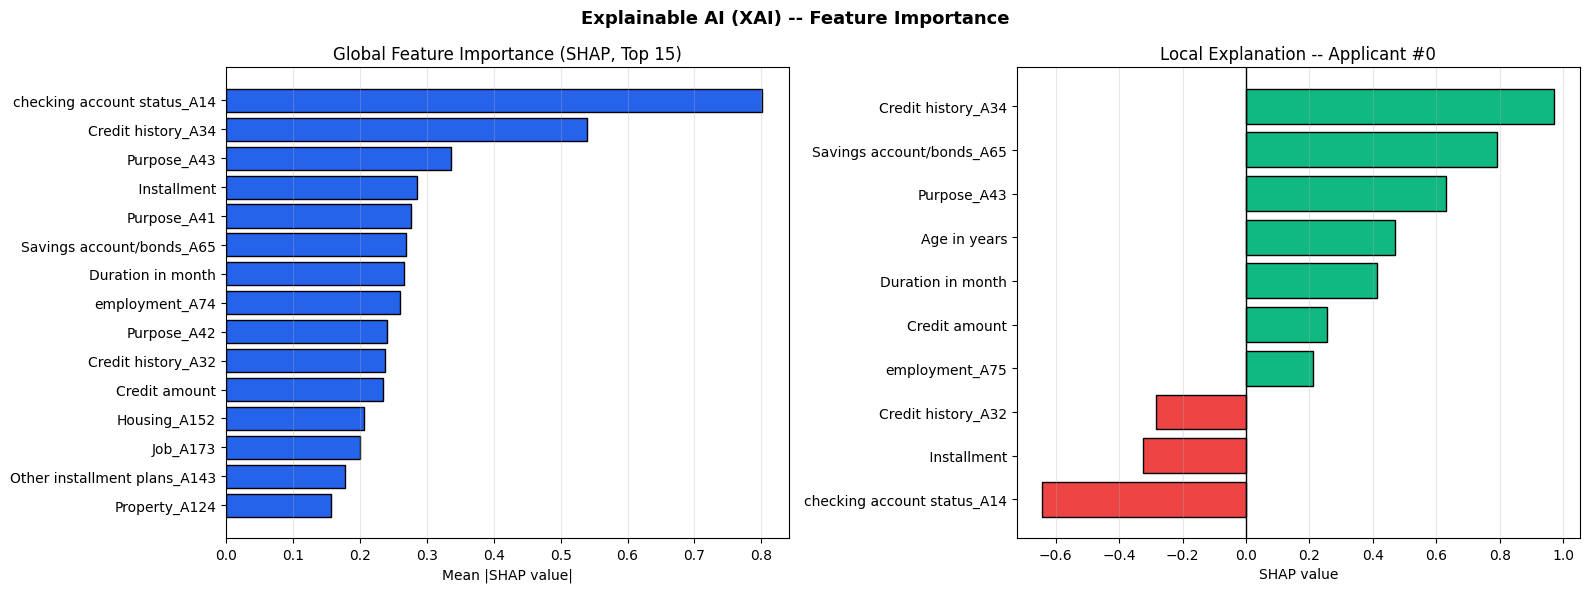

XAI plot saved (method: SHAP) to output\xai_feature_importance.png


In [8]:
feature_names = features_encoded.columns.tolist()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Explainable AI (XAI) -- Feature Importance', fontsize=13, fontweight='bold')


explainer   = shap.LinearExplainer(model, X_scaled, feature_names=feature_names)
shap_values = explainer.shap_values(X_scaled)
mean_abs    = np.abs(shap_values).mean(axis=0)
sdf = pd.DataFrame({'Feature': feature_names, 'SHAP': mean_abs})
sdf = sdf.nlargest(15, 'SHAP').sort_values('SHAP')
axes[0].barh(sdf['Feature'], sdf['SHAP'], color='#2563EB', edgecolor='k')
axes[0].set_xlabel('Mean |SHAP value|')
axes[0].set_title('Global Feature Importance (SHAP, Top 15)')
axes[0].grid(axis='x', alpha=0.3)
local_shap = shap_values[0]
ldf = pd.DataFrame({'Feature': feature_names, 'SHAP': local_shap})
ldf = ldf.reindex(ldf['SHAP'].abs().nlargest(10).index).sort_values('SHAP')
clrs = ['#EF4444' if v < 0 else '#10B981' for v in ldf['SHAP']]
axes[1].barh(ldf['Feature'], ldf['SHAP'], color=clrs, edgecolor='k')
axes[1].axvline(0, color='k', linewidth=1)
axes[1].set_xlabel('SHAP value')
axes[1].set_title('Local Explanation -- Applicant #0')
axes[1].grid(axis='x', alpha=0.3)
method = 'SHAP'


plt.tight_layout()
save_path = os.path.join(OUTPUT_DIR, 'xai_feature_importance.png')
plt.savefig(save_path, bbox_inches='tight')
plt.show()
print(f'XAI plot saved (method: {method}) to', save_path)


## Model Card

**Model Name**: Fairness Audit Tool  
**Dataset**: UCI German Credit Dataset (1000 applicants, 20 features)  

### Tool Purpose
Jurisdiction-aware algorithmic fairness auditing for credit scoring. Detects gender-based disparate impact across US and EU regulatory frameworks. Supports threshold sensitivity analysis and XAI explanations.

### Intended Use
The target market is focused on medium and large-sized banks, digital financial platforms, and fintech companies that require cross-border operations.

### Assumptions
- Gender is binary as encoded in the German dataset (A92/A95 = Female).
- Historical approvals (Category column) are treated as ground truth.
- Feature proxies for gender may exist -- indirect discrimination possible.

### Failure Modes
- **False Positive (unfair PASS)**: DIR/DPD can PASS at group level even when individual discrimination exists. Group parity does not guarantee individual fairness. Intersectional groups (e.g. elderly women) may face compounded disadvantage.
- **Performance Drift**: Model trained on 1994 German data. Risk distributions shift over time. EU AI Act Art. 72 requires periodic re-evaluation. Without monitoring, fairness metrics may degrade silently.
- **Jurisdictional Misconfiguration**: If thresholds in `JURISDICTION_CONFIG` are set incorrectly (e.g. 0.5 instead of 0.05 for EU DPD), the tool produces wrong audit results. Thresholds must be version-controlled and reviewed by legal counsel.
- **Proxy Discrimination**: Gender excluded from features but correlated variables (job type, loan purpose, housing) may still encode gender. XAI helps diagnose proxies but does not fully resolve indirect discrimination.

### Jurisdiction Divergence Example
A model with DIR=0.89 and DPD=0.075:
- **PASSES** US Regulation B (0.89 >= 0.80)
- **FAILS** EU AI Act (0.075 > 0.05)
